# MGEO RGC to IPC Progression

Focused notebook for testing whether MGEO progenitor/neurogenic cells recapitulate the fetal GE RGC to IPC progression described in Shi et al. Table S5.

This notebook starts from cached AnnData files. It does not reconvert Seurat objects and does not require the full Shi notebook state.

## Analysis Contract

- Use MGEO DIV30 and DIV90 only.
- Do not integrate Shi cells into this object.
- Use Shi Table S5 only as the published DEG source for RGC and IPC gene programs.
- Use MGEO AnnData expression values to score and visualize those programs.
- Frame results as conserved fetal GE progenitor-state progression, not lineage tracing.

## 1. Imports And Paths

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import spearmanr

import scanpy as sc

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]
if len(cwd.parents) >= 2:
    candidate_roots.append(cwd.parents[1])

for root in candidate_roots:
    src = root / "python_notebooks" / "src"
    if src.exists():
        sys.path.insert(0, str(src))
        repo_root = root
        break
else:
    raise RuntimeError("Could not locate python_notebooks/src from the current notebook directory")

from mge_organoid_python import default_studies, load_cached_anndata, resolve_project_root

PROJECT_ROOT = resolve_project_root()
table_s5_path = PROJECT_ROOT / "reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s5.xlsx"

print("repo_root =", repo_root)
print("PROJECT_ROOT =", PROJECT_ROOT)
print("Table S5 =", table_s5_path)

repo_root = /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
PROJECT_ROOT = /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder
Table S5 = /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s5.xlsx


## 2. Load Cached DIV30 And DIV90 AnnData

This loads the already converted `.h5ad` files. It does not rebuild them.

In [2]:
studies = {study.study_id: study for study in default_studies()}

div30, div30_report = load_cached_anndata(studies["varela_div30"], backed=None)
div90, div90_report = load_cached_anndata(studies["varela_div90"], backed=None)

print("DIV30:", div30.shape)
print("DIV90:", div90.shape)
print("DIV30 obs columns:", list(div30.obs.columns))
print("DIV90 obs columns:", list(div90.obs.columns))
print("DIV30 obsm keys:", list(div30.obsm.keys()))
print("DIV90 obsm keys:", list(div90.obsm.keys()))

DIV30: (90631, 18082)
DIV90: (22338, 18082)
DIV30 obs columns: ['cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.2', 'seurat_clusters']
DIV90 obs columns: ['cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.5', 'seurat_clusters', 'cluster_id', 'cluster_number_name']
DIV30 obsm keys: ['X_umap']
DIV90 obsm keys: ['X_umap']


## 3. Combine MGEO DIV30 And DIV90

DIV is preserved as biology. We do not regress it out and do not force DIV30/DIV90 overlap.

In [3]:
def add_div_metadata(adata, div_label):
    out = adata.copy()
    out.obs["DIV"] = div_label
    out.obs["source_h5ad"] = div_label
    out.obs["original_cell_id"] = out.obs_names.astype(str)
    return out

def ensure_sparse_float32(adata):
    if sparse.issparse(adata.X):
        adata.X = adata.X.astype(np.float32)
    else:
        adata.X = np.asarray(adata.X, dtype=np.float32)

div30 = add_div_metadata(div30, "DIV30")
div90 = add_div_metadata(div90, "DIV90")

mgeo = ad.concat(
    [div30, div90],
    axis=0,
    join="inner",
    label="DIV_source",
    keys=["DIV30", "DIV90"],
    index_unique="-",
)

ensure_sparse_float32(mgeo)
mgeo.obs["DIV"] = pd.Categorical(mgeo.obs["DIV"].astype(str), categories=["DIV30", "DIV90"], ordered=True)

print("Combined MGEO:", mgeo.shape)
print("Cells per DIV:")
display(mgeo.obs["DIV"].value_counts().reindex(["DIV30", "DIV90"]))

Combined MGEO: (112969, 18082)
Cells per DIV:


DIV
DIV30    90631
DIV90    22338
Name: count, dtype: int64

## 4. Build Shared MGEO PCA / Neighbors / UMAP

The converted matrices are already log-normalized, so we do not run `normalize_total` or `log1p` again.

In [4]:
n_top_genes = 3000
n_pcs = 50
neighbors_k = 20
random_seed = 7

if sparse.issparse(mgeo.X):
    nonzero = mgeo.X.data
else:
    nonzero = mgeo.X[mgeo.X > 0]

print("Expression sanity check")
print("min nonzero:", float(nonzero.min()) if len(nonzero) else 0)
print("max nonzero:", float(nonzero.max()) if len(nonzero) else 0)
print("mean nonzero:", float(nonzero.mean()) if len(nonzero) else 0)

print("Selecting HVGs...")
sc.pp.highly_variable_genes(mgeo, n_top_genes=n_top_genes, flavor="seurat", subset=False)
print("HVGs:", int(mgeo.var["highly_variable"].sum()))

mgeo_hvg = mgeo[:, mgeo.var["highly_variable"]].copy()
print("Scaling HVGs...")
sc.pp.scale(mgeo_hvg, max_value=10)

print("Running PCA...")
sc.tl.pca(mgeo_hvg, n_comps=n_pcs, svd_solver="arpack", random_state=random_seed)
mgeo.obsm["X_pca"] = mgeo_hvg.obsm["X_pca"]
mgeo.uns["pca"] = mgeo_hvg.uns["pca"]

print("Running neighbors...")
sc.pp.neighbors(mgeo, n_neighbors=neighbors_k, n_pcs=n_pcs, use_rep="X_pca", random_state=random_seed)

print("Running UMAP...")
sc.tl.umap(mgeo, random_state=random_seed)
print("UMAP complete.")

Expression sanity check
min nonzero: 0.2878488302230835
max nonzero: 7.482219219207764
mean nonzero: 1.110534429550171
Selecting HVGs...
HVGs: 3000
Scaling HVGs...


/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Running PCA...
Running neighbors...


/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running UMAP...
UMAP complete.


## 5. Load Shi Table S5 RGC / IPC DEGs

In [5]:
expected_cols = ["p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj", "cluster", "gene"]
expected_clusters = ["RGC", "IPC"]

def clean_gene_name(gene):
    if pd.isna(gene):
        return None
    gene = str(gene).strip()
    if gene == "" or gene.lower() in {"nan", "none", "na"}:
        return None
    if "00:00:00" in gene:
        return None
    return gene

s5 = pd.read_excel(table_s5_path, sheet_name="RGC IPC DEGs", header=1)
s5.columns = s5.columns.astype(str).str.strip()
s5 = s5.loc[:, ~s5.columns.str.lower().str.startswith("unnamed")].copy()

missing_cols = [c for c in expected_cols if c not in s5.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}. Observed: {list(s5.columns)}")

s5 = s5[expected_cols].copy()
s5["cluster"] = s5["cluster"].astype(str).str.strip()
s5["gene"] = s5["gene"].map(clean_gene_name)

for col in ["p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj"]:
    s5[col] = pd.to_numeric(s5[col], errors="coerce")

s5 = s5[s5["gene"].notna()].copy()
s5_sig = s5[s5["p_val_adj"] < 0.05].copy()

rgc_table = s5_sig[s5_sig["cluster"] == "RGC"].sort_values("avg_logFC", ascending=False).drop_duplicates("gene")
ipc_table = s5_sig[s5_sig["cluster"] == "IPC"].sort_values("avg_logFC", ascending=False).drop_duplicates("gene")

rgc_degs_published = rgc_table["gene"].tolist()
ipc_degs_published = ipc_table["gene"].tolist()

print("Table S5 shape:", s5.shape)
print("clusters:", sorted(s5["cluster"].dropna().unique().tolist()))
print("rows per cluster:")
display(s5["cluster"].value_counts().reindex(expected_clusters))
print("significant rows per cluster:")
display(s5_sig["cluster"].value_counts().reindex(expected_clusters))
print("Top 20 RGC:", rgc_degs_published[:20])
print("Top 20 IPC:", ipc_degs_published[:20])

Table S5 shape: (298, 7)
clusters: ['IPC', 'RGC']
rows per cluster:


cluster
RGC    148
IPC    150
Name: count, dtype: int64

significant rows per cluster:


cluster
RGC    148
IPC    150
Name: count, dtype: int64

Top 20 RGC: ['PTN', 'FABP7', 'VIM', 'HES1', 'TTYH1', 'CLU', 'SPARC', 'ID4', 'FGFBP3', 'CDO1', 'HES5', 'PEA15', 'BCAN', 'PTPRZ1', 'FAM107A', 'ZFP36L1', 'SFRP1', 'GPM6B', 'MEST', 'PON2']
Top 20 IPC: ['HIST1H4C', 'GAD2', 'UBE2C', 'DLX5', 'TOP2A', 'DLX6-AS1', 'SOX4', 'CENPF', 'HMGB2', 'DLX2', 'KPNA2', 'GADD45G', 'NUSAP1', 'MKI67', 'DLX1', 'STMN2', 'SMC4', 'TUBB4B', 'PTTG1', 'CDK1']


## 6. Score MGEO Cells With Table S5 Programs

In [6]:
def resolve_genes_to_anndata(adata, genes):
    var_names = pd.Index(adata.var_names.astype(str))
    upper_to_actual = {}
    for gene in var_names:
        upper_to_actual.setdefault(gene.upper(), gene)

    found = []
    missing = []
    for gene in genes:
        if gene in var_names:
            found.append(gene)
        elif gene.upper() in upper_to_actual:
            found.append(upper_to_actual[gene.upper()])
        else:
            missing.append(gene)

    return list(dict.fromkeys(found)), list(dict.fromkeys(missing))

def score_gene_set_mean_expression(adata, genes, score_name):
    if len(genes) == 0:
        raise ValueError(f"No genes available for {score_name}")
    x = adata[:, genes].X
    if sparse.issparse(x):
        score = np.asarray(x.mean(axis=1)).ravel()
    else:
        score = np.asarray(x).mean(axis=1)
    adata.obs[score_name] = score

rgc_degs, missing_rgc_degs = resolve_genes_to_anndata(mgeo, rgc_degs_published)
ipc_degs, missing_ipc_degs = resolve_genes_to_anndata(mgeo, ipc_degs_published)

score_gene_set_mean_expression(mgeo, rgc_degs, "shi_s5_RGC_score")
score_gene_set_mean_expression(mgeo, ipc_degs, "shi_s5_IPC_score")
mgeo.obs["shi_s5_IPC_minus_RGC_score"] = mgeo.obs["shi_s5_IPC_score"] - mgeo.obs["shi_s5_RGC_score"]

print("RGC found/missing:", len(rgc_degs), len(missing_rgc_degs), missing_rgc_degs[:20])
print("IPC found/missing:", len(ipc_degs), len(missing_ipc_degs), missing_ipc_degs[:20])
display(mgeo.obs[["shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"]].describe())

RGC found/missing: 135 13 ['CYR61', 'PPAP2B', 'GPR98', 'GCSH', 'SCRG1', 'LHFP', 'LINC00998', 'SNHG18', 'ALDOA', 'RPS14', 'EEF1D', 'LEPREL4', 'RPS12']
IPC found/missing: 134 16 ['DLX6-AS1', 'UBE2S', 'FAM64A', 'SOX11', 'HMGN2', 'SGOL1', 'SGOL2', 'OLA1', 'HN1', 'HMGB1', 'RACGAP1', 'TUBB3.1', 'H2AFV', 'CASC5', 'KIAA1524', 'PTMA']


,shi_s5_RGC_score,shi_s5_IPC_score,shi_s5_IPC_minus_RGC_score
count,112969.000000,112969.000000,112969.000000
mean,0.472941,0.461890,-0.011051
std,0.218329,0.236302,0.264045
min,0.000000,0.000000,-1.249448
25%,0.313919,0.317421,-0.122684
50%,0.413345,0.397574,0.014884
75%,0.609462,0.527692,0.115852
max,1.478610,1.895782,1.551055


## 7. Visualize RGC / IPC Scores

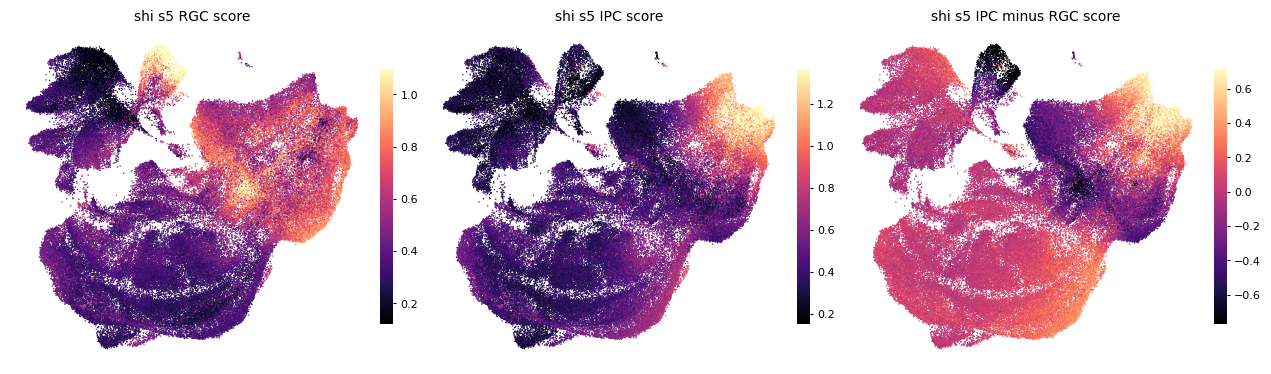

In [7]:
def plot_score_umap_grid(adata, score_names, ncols=3, point_size=1.0, cmap="magma", percentile_clip=99):
    coords = adata.obsm["X_umap"]
    n = len(score_names)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows), constrained_layout=True)
    axes = np.asarray(axes).ravel()

    for ax, score in zip(axes, score_names):
        values = pd.to_numeric(adata.obs[score], errors="coerce").to_numpy()
        valid = np.isfinite(values)
        vmax = np.nanpercentile(values[valid], percentile_clip)
        vmin = np.nanpercentile(values[valid], 1)
        sc_plot = ax.scatter(coords[valid, 0], coords[valid, 1], c=values[valid], s=point_size, cmap=cmap, vmin=vmin, vmax=vmax, linewidths=0, rasterized=True)
        ax.set_title(score.replace("_", " "), fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
        for spine in ax.spines.values():
            spine.set_visible(False)
        cbar = fig.colorbar(sc_plot, ax=ax, fraction=0.035, pad=0.015)
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(labelsize=8, length=2)

    for ax in axes[n:]:
        ax.axis("off")
    plt.show()

plot_score_umap_grid(mgeo, ["shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"], ncols=3, point_size=1.0)

## 8. Compare RGC / IPC Scores By DIV

shi_s5_RGC_score                               shi_s5_IPC_score  \
                 count      mean    median       std            count   
DIV                                                                     
DIV30            90631  0.497732  0.441765  0.202533            90631   
DIV90            22338  0.372358  0.311520  0.249061            22338   

                                    shi_s5_IPC_minus_RGC_score            \
           mean    median       std                      count      mean   
DIV                                                                        
DIV30  0.501461  0.429706  0.240895                      90631  0.003728   
DIV90  0.301342  0.288846  0.121732                      22338 -0.071016   

                           
         median       std  
DIV                        
DIV30  0.025718  0.263227  
DIV90 -0.021676  0.258829

,DIV90_minus_DIV30_median
shi_s5_RGC_score,-0.130245
shi_s5_IPC_score,-0.140860
shi_s5_IPC_minus_RGC_score,-0.047394


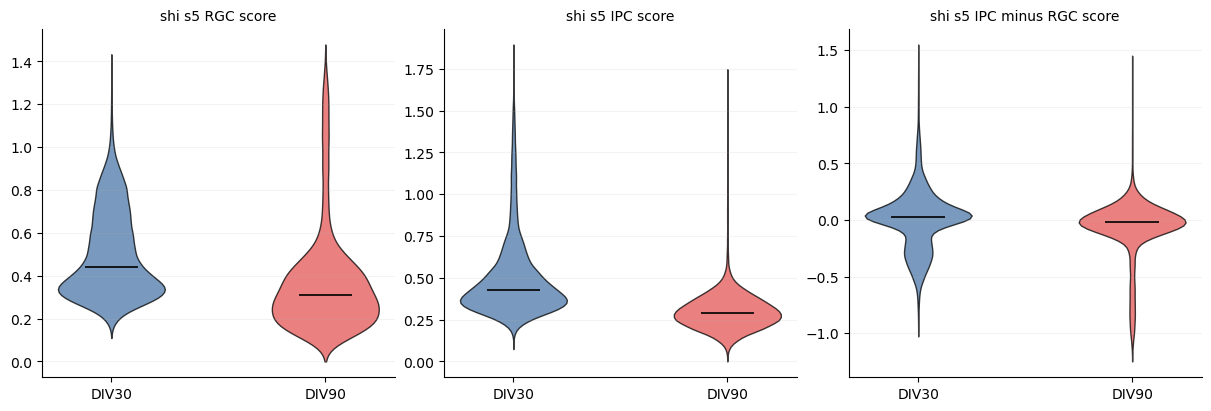

In [8]:
s5_score_cols = ["shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"]

s5_div_summary = mgeo.obs.groupby("DIV", observed=True)[s5_score_cols].agg(["count", "mean", "median", "std"])
display(s5_div_summary)

s5_div_delta = mgeo.obs.groupby("DIV", observed=True)[s5_score_cols].median()
display((s5_div_delta.loc["DIV90"] - s5_div_delta.loc["DIV30"]).to_frame("DIV90_minus_DIV30_median"))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, score in zip(axes, s5_score_cols):
    data = [
        mgeo.obs.loc[mgeo.obs["DIV"] == "DIV30", score].dropna().to_numpy(),
        mgeo.obs.loc[mgeo.obs["DIV"] == "DIV90", score].dropna().to_numpy(),
    ]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=True, showextrema=False)
    for body, color in zip(parts["bodies"], ["#4C78A8", "#E45756"]):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.75)
    if "cmedians" in parts:
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["DIV30", "DIV90"])
    ax.set_title(score.replace("_", " "), fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.15)
plt.show()

## 9. RGC-Rooted DPT Pseudotime

In [9]:
# ============================================================
# Focused RGC -> IPC DPT pseudotime
#
# Biological goal:
# Test whether MGEO progenitor/neurogenic cells recapitulate
# the fetal GE RGC-to-IPC progression described by Shi Table S5.
#
# Important:
# - Do NOT run this RGC->IPC pseudotime on all MGEO cells.
# - First keep cells with meaningful RGC or IPC program activity.
# - Optionally remove the most mature/synaptic cells so this remains
#   a progenitor/neurogenic analysis, not terminal interneuron tracing.
# ============================================================

# A cell enters this focused subset if either its RGC or IPC score is high enough.
# This keeps progenitor/neurogenic cells and removes cells low for both programs.
rgc_ipc_activity = mgeo.obs[["shi_s5_RGC_score", "shi_s5_IPC_score"]].max(axis=1)
activity_quantile = 0.30  # keep top 70% by max(RGC, IPC); adjust to 0.20 to keep top 80%
activity_cutoff = rgc_ipc_activity.quantile(activity_quantile)

subset_mask = rgc_ipc_activity >= activity_cutoff

# Optional safeguard: if a synaptic maturation score exists, remove the most mature cells.
# This keeps the analysis focused on RGC/IPC progenitor-neurogenic progression.
exclude_most_mature = True
mature_exclusion_quantile = 0.95

if exclude_most_mature and "maturation_synaptic_score" in mgeo.obs.columns:
    mature_score = pd.to_numeric(mgeo.obs["maturation_synaptic_score"], errors="coerce")
    mature_cutoff = mature_score.quantile(mature_exclusion_quantile)
    subset_mask = subset_mask & (mature_score <= mature_cutoff)
else:
    mature_cutoff = np.nan

mgeo_rgc_ipc = mgeo[subset_mask.to_numpy(), :].copy()

print("Focused MGEO RGC/IPC subset")
print("---------------------------")
print("activity quantile cutoff:", activity_quantile)
print("activity cutoff:", activity_cutoff)
print("exclude most mature:", exclude_most_mature)
print("mature exclusion quantile:", mature_exclusion_quantile)
print("mature cutoff:", mature_cutoff)
print("subset shape:", mgeo_rgc_ipc.shape)
print("fraction of MGEO retained:", mgeo_rgc_ipc.n_obs / mgeo.n_obs)

print("
DIV composition in focused subset:")
display(mgeo_rgc_ipc.obs["DIV"].value_counts().reindex(["DIV30", "DIV90"]))

display(
    mgeo_rgc_ipc.obs[
        ["shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"]
    ].describe()
)

# Recompute neighbors within the focused subset using the existing MGEO PCA coordinates.
# This makes the trajectory local to the RGC/IPC-enriched compartment.
print("Running neighbors for focused RGC/IPC DPT...")
sc.pp.neighbors(
    mgeo_rgc_ipc,
    n_neighbors=20,
    n_pcs=50,
    use_rep="X_pca",
    random_state=7,
)

print("Running diffusion map...")
sc.tl.diffmap(mgeo_rgc_ipc)

# Root cells should be DIV30, RGC-high, IPC-low.
root_df = mgeo_rgc_ipc.obs[
    ["DIV", "shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"]
].copy()

for col in ["shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"]:
    root_df[col] = pd.to_numeric(root_df[col], errors="coerce")

root_df = root_df.dropna().copy()

root_candidates = root_df[
    (root_df["DIV"] == "DIV30")
    & (root_df["shi_s5_RGC_score"] >= root_df["shi_s5_RGC_score"].quantile(0.90))
    & (root_df["shi_s5_IPC_score"] <= root_df["shi_s5_IPC_score"].quantile(0.50))
].copy()

# Relax root if needed, but keep it RGC-high and DIV30-biased when possible.
if len(root_candidates) < 25:
    root_candidates = root_df[
        (root_df["DIV"] == "DIV30")
        & (root_df["shi_s5_RGC_score"] >= root_df["shi_s5_RGC_score"].quantile(0.80))
    ].copy()

if len(root_candidates) == 0:
    root_candidates = root_df[
        root_df["shi_s5_RGC_score"] >= root_df["shi_s5_RGC_score"].quantile(0.95)
    ].copy()

if len(root_candidates) == 0:
    raise RuntimeError("No RGC-root candidates found. Lower the activity cutoff or root thresholds.")

root_candidates["rgc_root_score"] = (
    root_candidates["shi_s5_RGC_score"]
    - root_candidates["shi_s5_IPC_score"]
)

rgc_root_cell = root_candidates["rgc_root_score"].idxmax()
rgc_root_index = int(np.where(mgeo_rgc_ipc.obs_names == rgc_root_cell)[0][0])
mgeo_rgc_ipc.uns["iroot"] = rgc_root_index

print("
RGC-rooted DPT root")
print("-------------------")
print("root cell:", rgc_root_cell)
print("root candidates:", len(root_candidates))
display(
    mgeo_rgc_ipc.obs.loc[
        [rgc_root_cell],
        ["DIV", "shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"],
    ]
)

print("Running DPT...")
sc.tl.dpt(mgeo_rgc_ipc)
mgeo_rgc_ipc.obs["rgc_ipc_pseudotime"] = mgeo_rgc_ipc.obs["dpt_pseudotime"]

# Map focused pseudotime back to the full MGEO object.
# Cells outside the focused subset remain NaN by design.
mgeo.obs["rgc_ipc_pseudotime"] = np.nan
mgeo.obs.loc[mgeo_rgc_ipc.obs_names, "rgc_ipc_pseudotime"] = mgeo_rgc_ipc.obs["rgc_ipc_pseudotime"]

print("
RGC/IPC pseudotime summary in focused subset:")
display(mgeo_rgc_ipc.obs["rgc_ipc_pseudotime"].describe())

print("
Mapped pseudotime back to mgeo.obs['rgc_ipc_pseudotime'].")
print("Cells with pseudotime:", int(mgeo.obs["rgc_ipc_pseudotime"].notna().sum()))
print("Cells outside focused subset:", int(mgeo.obs["rgc_ipc_pseudotime"].isna().sum()))



Running neighbors for RGC/IPC DPT...
Running diffusion map...
RGC root cell: GATTAGTCATTGCATCAGAGGCAA-1-DIV30


,DIV,shi_s5_RGC_score,shi_s5_IPC_score
cell_id,,,
GATTAGTCATTGCATCAGAGGCAA-1-DIV30,DIV30,1.394952,0.366532


Running DPT...


count    112969.000000
mean          0.350051
std           0.159480
min           0.000000
25%           0.216843
50%           0.380193
75%           0.436093
max           1.000000
Name: rgc_ipc_pseudotime, dtype: float64

## 10. Validate RGC Decrease And IPC Increase Along Pseudotime

,score,spearman_r_vs_rgc_ipc_pseudotime,p_value,expected_direction
0,shi_s5_RGC_score,-0.590866,0.0,negative
1,shi_s5_IPC_score,-0.356770,0.0,positive
2,shi_s5_IPC_minus_RGC_score,0.239366,0.0,positive


,pt_bin,pseudotime_median,n_cells,RGC_score_median,IPC_score_median,IPC_minus_RGC_median,fraction_DIV90
0,0,0.052106,4519,0.759754,0.368670,-0.379733,0.000221
1,1,0.104375,4519,0.702777,0.444009,-0.248504,0.000443
2,2,0.125680,4519,0.690408,0.468866,-0.216493,0.000885
3,3,0.150895,4518,0.654359,0.470017,-0.169131,0.007304
4,4,0.177053,4519,0.634106,0.436569,-0.193330,0.006639
5,5,0.200026,4519,0.615441,0.390354,-0.216431,0.006196
6,6,0.222678,4519,0.607970,0.403903,-0.179947,0.014605
7,7,0.248483,4518,0.591791,0.633301,0.050653,0.027888
8,8,0.287437,4519,0.507609,0.681473,0.171479,0.030759
9,9,0.325127,4519,0.406874,0.590931,0.190134,0.039832


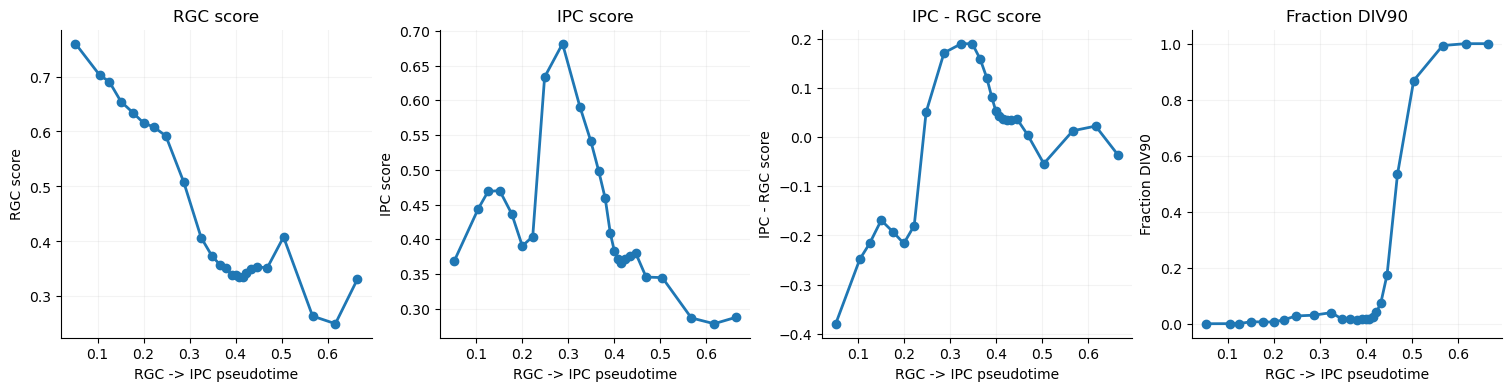

In [10]:
trend_df = mgeo.obs[["DIV", "rgc_ipc_pseudotime", "shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"]].copy()
for col in ["rgc_ipc_pseudotime", "shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"]:
    trend_df[col] = pd.to_numeric(trend_df[col], errors="coerce")
trend_df = trend_df.dropna().copy()

correlation_rows = []
for score in ["shi_s5_RGC_score", "shi_s5_IPC_score", "shi_s5_IPC_minus_RGC_score"]:
    r, p = spearmanr(trend_df["rgc_ipc_pseudotime"], trend_df[score])
    correlation_rows.append({
        "score": score,
        "spearman_r_vs_rgc_ipc_pseudotime": r,
        "p_value": p,
        "expected_direction": "negative" if score == "shi_s5_RGC_score" else "positive",
    })
display(pd.DataFrame(correlation_rows))

trend_df["pt_bin"] = pd.qcut(trend_df["rgc_ipc_pseudotime"], q=25, labels=False, duplicates="drop")
rgc_ipc_binned_trends = trend_df.groupby("pt_bin", observed=True).agg(
    pseudotime_median=("rgc_ipc_pseudotime", "median"),
    n_cells=("rgc_ipc_pseudotime", "size"),
    RGC_score_median=("shi_s5_RGC_score", "median"),
    IPC_score_median=("shi_s5_IPC_score", "median"),
    IPC_minus_RGC_median=("shi_s5_IPC_minus_RGC_score", "median"),
    fraction_DIV90=("DIV", lambda x: np.mean(x.astype(str) == "DIV90")),
).reset_index()
display(rgc_ipc_binned_trends)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), constrained_layout=True)
plot_specs = [
    ("RGC_score_median", "RGC score"),
    ("IPC_score_median", "IPC score"),
    ("IPC_minus_RGC_median", "IPC - RGC score"),
    ("fraction_DIV90", "Fraction DIV90"),
]
for ax, (col, title) in zip(axes, plot_specs):
    ax.plot(rgc_ipc_binned_trends["pseudotime_median"], rgc_ipc_binned_trends[col], marker="o", linewidth=2)
    ax.set_xlabel("RGC -> IPC pseudotime")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.15)
plt.show()

## 11. Table S5 Gene Heatmap Ordered By MGEO Pseudotime

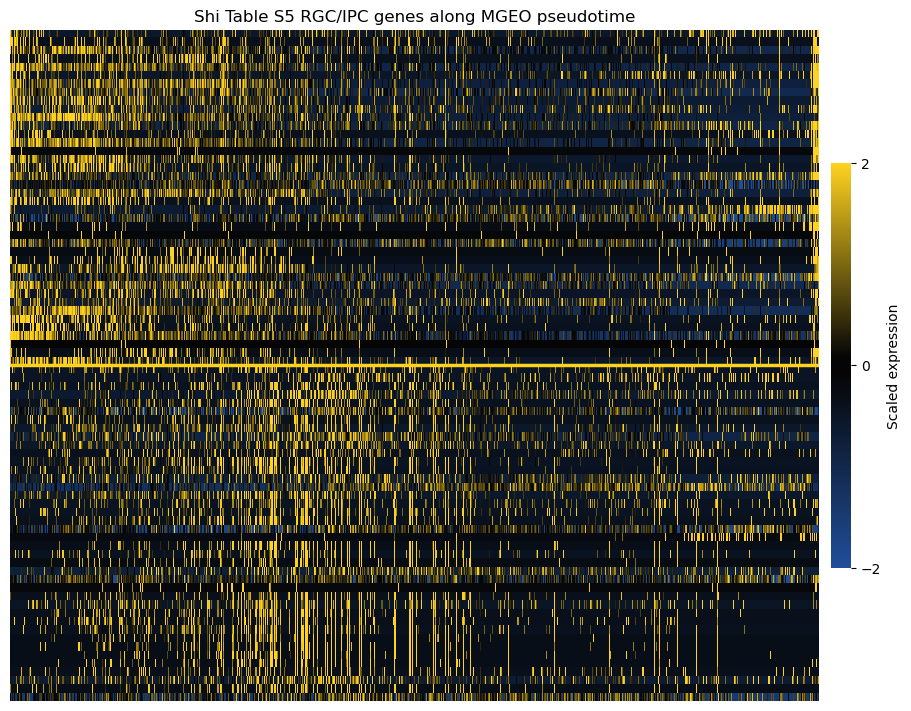

In [11]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

top_heatmap_n = 40
max_heatmap_cells = 6000

rgc_heatmap_genes = rgc_degs[:top_heatmap_n]
ipc_heatmap_genes = ipc_degs[:top_heatmap_n]
rgc_ipc_heatmap_genes = rgc_heatmap_genes + ipc_heatmap_genes

ordered_cells = mgeo.obs.sort_values("rgc_ipc_pseudotime").index
if len(ordered_cells) > max_heatmap_cells:
    idx = np.linspace(0, len(ordered_cells) - 1, max_heatmap_cells).astype(int)
    ordered_cells_plot = ordered_cells[idx]
else:
    ordered_cells_plot = ordered_cells

x = mgeo[ordered_cells_plot, rgc_ipc_heatmap_genes].X
if sparse.issparse(x):
    x = x.toarray()
x = np.asarray(x, dtype=float)

mean = np.nanmean(x, axis=0, keepdims=True)
std = np.nanstd(x, axis=0, keepdims=True)
std[std == 0] = 1.0
z = np.clip((x - mean) / std, -2, 2)
heatmap_matrix = z.T

cmap = LinearSegmentedColormap.from_list("blue_black_gold", [(0.00, "#1f4e99"), (0.48, "#050505"), (0.52, "#050505"), (1.00, "#ffd21f")])

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
im = ax.imshow(heatmap_matrix, aspect="auto", interpolation="nearest", cmap=cmap, norm=mpl.colors.TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2), rasterized=True)
ax.axhline(len(rgc_heatmap_genes) - 0.5, color="#ffd21f", linewidth=2.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Shi Table S5 RGC/IPC genes along MGEO pseudotime")
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.015, ticks=[-2, 0, 2])
cbar.outline.set_visible(False)
cbar.set_label("Scaled expression")
plt.show()